# Task definition and dataset audit

This notebook converts CAT-SG's frame annotations into a reproducible next-instrument anticipation cohort. It audits the data before modeling and fixes every cohort decision using training procedures only.

## 1. Study contract

**Question.** At a fixed three-second horizon, do scene-graph relations improve prediction of the next instrument set beyond instrument-presence history alone?

CAT-SG does not annotate handovers. The observable target is therefore a **set of confirmed instrument onsets**: instruments first appearing at the same timestamp after at least eight seconds of absence. This is a proxy for instruments becoming relevant in the surgical field, not proof that a scrub nurse handed them to the surgeon.

In [1]:
from collections import Counter
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "annotations").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_ROOT = PROJECT_ROOT / "data" / "annotations"
SPLIT_ROOT = DATA_ROOT / "splits"
RESULTS_ROOT = PROJECT_ROOT / "results"
FIGURES_ROOT = PROJECT_ROOT / "figures"

ANNOTATION_FPS = 5
OBSERVATION_SECONDS = 5
HORIZON_SECONDS = 3
OBSERVATION_FRAMES = OBSERVATION_SECONDS * ANNOTATION_FPS
HORIZON_FRAMES = HORIZON_SECONDS * ANNOTATION_FPS
PRIOR_ABSENCE_FRAMES = OBSERVATION_FRAMES + HORIZON_FRAMES
CONFIRMATION_WINDOW_FRAMES = ANNOTATION_FPS
MIN_CONFIRMATION_FRAMES = 3
MIN_TRAIN_EVENTS = 15
MIN_TRAIN_PROCEDURES = 8

SPLIT_ORDER = ["train", "val", "test"]
EXPECTED_SPLIT_SIZES = {"train": 25, "val": 5, "test": 20}
NON_TARGET_ENTITIES = frozenset(
    {"Pupil", "Iris", "Cornea", "Skin", "Surgical Tape", "Hand", "Eye Retractors"}
)
REQUIRED_FRAME_FIELDS = frozenset(
    {"entities", "geometric_relations", "semantic_relations", "step",
     "technique", "bounding_box", "pos", "size"}
)

pd.set_option("display.max_rows", 40)
pd.set_option("display.max_colwidth", 100)

assert DATA_ROOT.exists(), f"CAT-SG annotations not found at {DATA_ROOT}"

## 2. Dataset partition and schema

The official procedure-level split is preserved. Frames from one procedure never cross partitions. The audit checks file counts, frame schema, sampling density and the observed graph vocabulary without modifying the split.

In [2]:
split_files = {
    "train": sorted((SPLIT_ROOT / "train" / "raw").glob("*.json")),
    "val": sorted((SPLIT_ROOT / "val").glob("*/raw/*.json")),
    "test": sorted((SPLIT_ROOT / "test").glob("*/raw/*.json")),
}

actual_split_sizes = {split: len(files) for split, files in split_files.items()}
assert actual_split_sizes == EXPECTED_SPLIT_SIZES, actual_split_sizes

split_summary = pd.DataFrame(
    {
        "split": SPLIT_ORDER,
        "procedures": [len(split_files[split]) for split in SPLIT_ORDER],
        "procedure_ids": [", ".join(path.stem for path in split_files[split]) for split in SPLIT_ORDER],
    }
)
display(split_summary)

,split,procedures,procedure_ids
0,train,25,"train01, train02, train03, train04, train05, train06, train07, train08, train09, train10, train1..."
1,val,5,"test01, test07, test14, test16, test19"
2,test,20,"test02, test03, test04, test05, test06, test08, test09, test10, test11, test12, test13, test15, ..."


In [3]:
procedure_rows = []
observed_entities = {split: set() for split in SPLIT_ORDER}
entity_frame_counts = {split: Counter() for split in SPLIT_ORDER}
relation_counts = {split: Counter() for split in SPLIT_ORDER}
schema_errors = []

for split in SPLIT_ORDER:
    for annotation_file in split_files[split]:
        with annotation_file.open() as file_handle:
            payload = json.load(file_handle)

        ordered_frames = sorted(payload.items(), key=lambda item: int(item[0]))
        source_frame_numbers = np.fromiter((int(key) for key, _ in ordered_frames), dtype=int)

        for frame_key, frame in ordered_frames:
            missing_fields = REQUIRED_FRAME_FIELDS.difference(frame)
            if missing_fields:
                schema_errors.append((annotation_file.name, frame_key, sorted(missing_fields)))

            observed_entities[split].update(frame["entities"])
            entity_frame_counts[split].update(set(frame["entities"]))
            relation_counts[split]["Close to"] += len(frame["geometric_relations"])
            relation_counts[split].update(relation[1] for relation in frame["semantic_relations"])

        procedure_rows.append(
            {
                "split": split,
                "procedure": annotation_file.stem,
                "annotated_frames": len(ordered_frames),
                "duration_minutes": len(ordered_frames) / ANNOTATION_FPS / 60,
                "median_source_frame_stride": float(np.median(np.diff(source_frame_numbers))),
            }
        )

assert not schema_errors, schema_errors[:5]
procedure_stats = pd.DataFrame(procedure_rows)

display(
    procedure_stats.groupby("split", sort=False)
    .agg(
        procedures=("procedure", "nunique"),
        annotated_frames=("annotated_frames", "sum"),
        median_duration_minutes=("duration_minutes", "median"),
        median_source_frame_stride=("median_source_frame_stride", "median"),
    )
    .round(2)
)

relation_summary = pd.DataFrame(relation_counts).fillna(0).astype(int)
display(relation_summary.loc[:, SPLIT_ORDER])

,procedures,annotated_frames,median_duration_minutes,median_source_frame_stride
split,,,,
train,25,84811,9.12,6.0
val,5,18525,12.55,6.0
test,20,60826,8.83,6.0


,train,val,test
Close to,820519,236627,620578
Holding,7013,1763,4604
Cutting,951,291,683
Retracting,14804,2227,6855
Inserting,18303,3265,12448
Activation,32040,3836,8676
Pulling,4121,1367,6407
Pushing,1974,468,1432


## 3. Instrument vocabulary

The target ontology excludes anatomy, the surgical tape, the surgeon's hand and the eye retractors, which are setup equipment rather than a dynamically requested instrument. Eligibility is then determined **only from training events**: an instrument must contribute at least 15 events across at least eight training procedures. The validation and test partitions cannot add labels to the vocabulary.

In [4]:
all_observed_entities = set().union(*observed_entities.values())
candidate_instruments = sorted(all_observed_entities.difference(NON_TARGET_ENTITIES))

entity_rows = []
for entity in sorted(all_observed_entities):
    entity_rows.append(
        {
            "entity": entity,
            "role": "instrument" if entity in candidate_instruments else "context",
            **{f"{split}_frames": entity_frame_counts[split][entity] for split in SPLIT_ORDER},
        }
    )

entity_summary = pd.DataFrame(entity_rows)
display(entity_summary.query("role == 'instrument'").reset_index(drop=True))

,entity,role,train_frames,val_frames,test_frames
0,Bonn Forceps,instrument,2843,1012,2058
1,Cap. Cystotome,instrument,4108,877,3473
2,Cap. Forceps,instrument,2641,850,1048
3,Charleux Cannula,instrument,1613,459,221
4,Cotton,instrument,856,40,115
5,Hydro. Cannula,instrument,2862,717,1716
6,I/A Handpiece,instrument,13175,3798,12267
7,Iris Hooks,instrument,3586,104,245
8,Lens Injector,instrument,2828,935,2104
9,Marker,instrument,3069,1654,2664


## 4. Anticipation-event construction

For an onset at index $t$, the target instrument must be absent from the preceding 40 annotations (eight seconds) and present in at least three of the five annotations beginning at $t$. The model observes the first 25 annotations of that absence interval. The following 15 annotations form the three-second forecast gap. Consequently, the target is absent from every input frame and from the complete forecast gap.

The one-second confirmation suppresses isolated segmentation flicker. It is used only to construct the label and is never exposed to a model. Instruments satisfying the rule at the same timestamp are grouped into one multi-label target set; this retains potentially coordinated or bimanual activity without claiming that CAT-SG identifies its cause.

In [5]:
def extract_instrument_onsets(annotation_file, split, targets):
    with annotation_file.open() as file_handle:
        payload = json.load(file_handle)

    ordered_frames = sorted(payload.items(), key=lambda item: int(item[0]))
    frame_keys = [key for key, _ in ordered_frames]
    records = [record for _, record in ordered_frames]
    presence = [set(record["entities"]).intersection(targets) for record in records]
    last_seen = {target: -1 for target in targets}
    onset_rows = []

    for event_index, present_targets in enumerate(presence):
        enough_history = event_index >= PRIOR_ABSENCE_FRAMES
        enough_confirmation = event_index + CONFIRMATION_WINDOW_FRAMES <= len(presence)

        if enough_history and enough_confirmation:
            for target in sorted(present_targets):
                previous_index = last_seen[target]
                prior_absence = event_index if previous_index < 0 else event_index - previous_index - 1
                confirmation_count = sum(
                    target in presence[index]
                    for index in range(event_index, event_index + CONFIRMATION_WINDOW_FRAMES)
                )

                if prior_absence >= PRIOR_ABSENCE_FRAMES and confirmation_count >= MIN_CONFIRMATION_FRAMES:
                    observation_start = event_index - PRIOR_ABSENCE_FRAMES
                    observation_end = event_index - HORIZON_FRAMES - 1
                    onset_rows.append(
                        {
                            "split": split,
                            "procedure": annotation_file.stem,
                            "target": target,
                            "observation_start_frame": int(frame_keys[observation_start]),
                            "observation_end_frame": int(frame_keys[observation_end]),
                            "event_frame": int(frame_keys[event_index]),
                            "event_step": records[event_index]["step"],
                            "event_technique": records[event_index]["technique"],
                            "prior_absence_frames": prior_absence,
                            "confirmation_frames": confirmation_count,
                        }
                    )

        for target in present_targets:
            last_seen[target] = event_index

    return onset_rows


event_rows = []
for split in SPLIT_ORDER:
    for annotation_file in split_files[split]:
        event_rows.extend(extract_instrument_onsets(annotation_file, split, candidate_instruments))

all_events = pd.DataFrame(event_rows)
assert not all_events.empty
assert all_events["prior_absence_frames"].ge(PRIOR_ABSENCE_FRAMES).all()

event_key = ["split", "procedure", "event_frame"]
train_support = (
    all_events.query("split == 'train'")
    .groupby("target")
    .agg(train_events=("target", "size"), train_procedures=("procedure", "nunique"))
)
eligible_targets = sorted(
    train_support.query(
        "train_events >= @MIN_TRAIN_EVENTS and train_procedures >= @MIN_TRAIN_PROCEDURES"
    ).index
)
assert eligible_targets, "The training-only eligibility rule produced an empty vocabulary."

event_sets = (
    all_events.groupby(event_key, as_index=False, sort=False)
    .agg(
        observation_start_frame=("observation_start_frame", "first"),
        observation_end_frame=("observation_end_frame", "first"),
        event_step=("event_step", "first"),
        event_technique=("event_technique", "first"),
        all_targets=("target", lambda values: tuple(sorted(set(values)))),
        minimum_prior_absence_frames=("prior_absence_frames", "min"),
        minimum_confirmation_frames=("confirmation_frames", "min"),
    )
)
event_sets["targets"] = event_sets["all_targets"].map(
    lambda values: tuple(target for target in values if target in eligible_targets)
)
event_sets["all_target_count"] = event_sets["all_targets"].map(len)
event_sets["target_count"] = event_sets["targets"].map(len)
event_sets["multi_instrument"] = event_sets["all_target_count"].gt(1)
model_events = event_sets.query("target_count > 0").reset_index(drop=True)
singleton_events = model_events.query("not multi_instrument").reset_index(drop=True)
assert not model_events.duplicated(event_key).any()

,train_events,train_procedures,train,val,test,eligible
target,,,,,,
Rycroft Cannula,93,25,93,11,47,True
Bonn Forceps,63,23,63,15,39,True
Micromanipulator,61,20,61,12,48,True
Visc. Cannula,58,25,58,17,39,True
I/A Handpiece,57,23,57,13,50,True
Lens Injector,33,21,33,9,25,True
Hydro. Cannula,32,18,32,6,19,True
Primary Knife,29,20,29,15,35,True
Secondary Knife,23,18,23,7,19,True


,split,confirmed_onset_labels,event_sets,multi_instrument_sets,modeled_event_sets,partial_vocabulary_sets,eligible_label_coverage
0,train,600,582,17,520,7,0.885
1,val,163,157,6,135,3,0.847
2,test,403,392,11,361,2,0.918


,,event_sets
instrument_set,event_step,
Bonn Forceps + Secondary Knife,Incision,8
Bonn Forceps + Primary Knife,Incision,4
Suture Needle + Troutman Forceps,Suturing,2
Micromanipulator + Troutman Forceps,Preparing Implant,2
I/A Handpiece + Rycroft Cannula,OVD Aspiration,1
Suture Needle + Troutman Forceps,Preparing Implant,1
Primary Knife + Suture Needle + Troutman Forceps,Preparing Implant,1
Needle Holder + Suture Needle,Suturing,1
Needle Holder + Ph. Handpiece,Idle,1


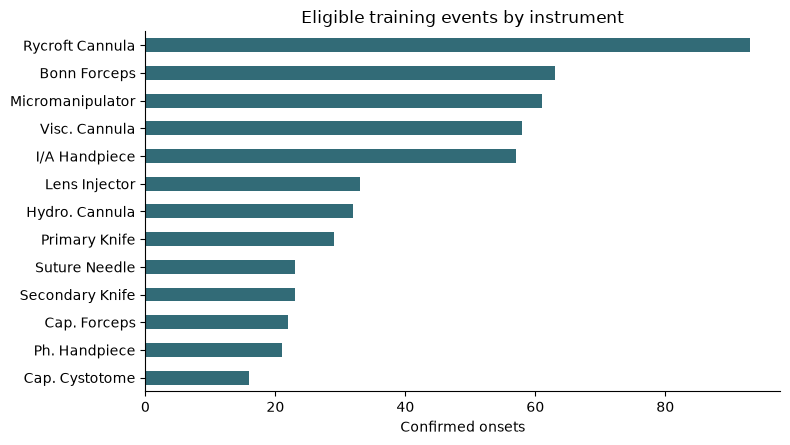

In [6]:
event_counts = (
    all_events.groupby(["target", "split"]).size().unstack(fill_value=0).reindex(columns=SPLIT_ORDER, fill_value=0)
)
support_table = train_support.join(event_counts).fillna(0).astype(int)
support_table["eligible"] = support_table.index.isin(eligible_targets)
display(support_table.sort_values(["eligible", "train_events"], ascending=False))

coverage_rows = []
for split in SPLIT_ORDER:
    split_labels = all_events.query("split == @split")
    split_event_sets = event_sets.query("split == @split")
    split_model_events = model_events.query("split == @split")
    coverage_rows.append(
        {
            "split": split,
            "confirmed_onset_labels": len(split_labels),
            "event_sets": len(split_event_sets),
            "multi_instrument_sets": int(split_event_sets["multi_instrument"].sum()),
            "modeled_event_sets": len(split_model_events),
            "partial_vocabulary_sets": int(
                split_model_events["all_target_count"].gt(split_model_events["target_count"]).sum()
            ),
            "eligible_label_coverage": split_labels["target"].isin(eligible_targets).mean(),
        }
    )
display(pd.DataFrame(coverage_rows).round(3))

combination_summary = (
    model_events.query("multi_instrument")
    .assign(instrument_set=lambda frame: frame["all_targets"].map(" + ".join))
    .groupby(["instrument_set", "event_step"]).size()
    .rename("event_sets").sort_values(ascending=False).to_frame()
)
display(combination_summary.head(15))

plot_counts = support_table.loc[eligible_targets, "train"].sort_values()
ax = plot_counts.plot.barh(figsize=(8, max(3, 0.35 * len(plot_counts))), color="#326B77")
ax.set(title="Eligible training events by instrument", xlabel="Confirmed onsets", ylabel="")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
FIGURES_ROOT.mkdir(exist_ok=True)
plt.savefig(FIGURES_ROOT / "01_training_event_support.png", dpi=160, bbox_inches="tight")
plt.show()

## 5. Locked protocol

The multi-label cohort below is the primary input to the modeling notebook; the singleton-only subset is retained as a sensitivity analysis. Test procedures remain untouched during model and hyperparameter selection. A topology-specific interpretation is reserved for improvement over the entity-history model that is not retained by either the no-edge or shuffled-edge control.

In [7]:
protocol = {
    "question": "Do scene-graph relations improve next-instrument-set anticipation beyond entity history?",
    "target": "set of confirmed instrument onsets after eight seconds of absence",
    "annotation_fps": ANNOTATION_FPS,
    "observation_seconds": OBSERVATION_SECONDS,
    "horizon_seconds": HORIZON_SECONDS,
    "confirmation_rule": {
        "window_frames": CONFIRMATION_WINDOW_FRAMES,
        "minimum_present_frames": MIN_CONFIRMATION_FRAMES,
    },
    "multi_instrument_rule": "group confirmed onsets at the same timestamp into one target set",
    "vocabulary_rule": {
        "minimum_training_events": MIN_TRAIN_EVENTS,
        "minimum_training_procedures": MIN_TRAIN_PROCEDURES,
    },
    "eligible_targets": eligible_targets,
    "split_sizes": EXPECTED_SPLIT_SIZES,
    "models": [
        "frequency/Markov", "entity GRU", "no-edge control",
        "shuffled-edge control", "temporal GNN"
    ],
    "out_of_vocabulary_rule": (
        "retain event sets containing at least one eligible target, preserve all observed targets for audit, "
        "and score only targets in the training-derived vocabulary"
    ),
    "metrics": ["Recall@1", "Recall@3", "sample-averaged mean average precision"],
    "seeds": [7, 21, 73],
    "primary_comparison": "temporal GNN versus entity GRU",
    "interpretation_rule": (
        "A topology-specific interpretation requires gains in Recall@3 and sample-averaged mean average precision "
        "over the entity GRU, no-edge control and shuffled-edge control."
    ),
    "sensitivity_analysis": "evaluate the fitted primary models on singleton-only test event sets",
}

RESULTS_ROOT.mkdir(exist_ok=True)
def serialise_target_sets(frame):
    exported = frame.copy()
    for column in ["all_targets", "targets"]:
        exported[column] = exported[column].map(json.dumps)
    return exported

serialise_target_sets(model_events).to_csv(RESULTS_ROOT / "anticipation_events.csv", index=False)
serialise_target_sets(singleton_events).to_csv(RESULTS_ROOT / "anticipation_events_singleton.csv", index=False)
with (RESULTS_ROOT / "task_protocol.json").open("w") as file_handle:
    json.dump(protocol, file_handle, indent=2)
    file_handle.write("\n")

display(pd.Series(protocol, name="value").to_frame())
print(
    f"Wrote {len(model_events):,} event sets across {len(eligible_targets)} targets; "
    f"{int(model_events['multi_instrument'].sum()):,} are multi-instrument and "
    f"{len(singleton_events):,} form the singleton sensitivity cohort."
)

,value
question,Do scene-graph relations improve next-instrument-set anticipation beyond entity history?
target,set of confirmed instrument onsets after eight seconds of absence
annotation_fps,5
observation_seconds,5
horizon_seconds,3
confirmation_rule,"{'window_frames': 5, 'minimum_present_frames': 3}"
multi_instrument_rule,group confirmed onsets at the same timestamp into one target set
vocabulary_rule,"{'minimum_training_events': 15, 'minimum_training_procedures': 8}"
eligible_targets,"[Bonn Forceps, Cap. Cystotome, Cap. Forceps, Hydro. Cannula, I/A Handpiece, Lens Injector, Micro..."
split_sizes,"{'train': 25, 'val': 5, 'test': 20}"


Wrote 1,016 event sets across 13 targets; 34 are multi-instrument and 982 form the singleton sensitivity cohort.


## Interpretation

The frozen cohort contains 1,016 event sets across 13 modeled instruments: 520 training, 135 validation and 361 test examples. It retains 34 multi-instrument sets; the remaining 982 examples form the singleton sensitivity cohort. The training-derived vocabulary covers 88.5% of confirmed training labels, 84.7% of validation labels and 91.8% of test labels. Rare out-of-vocabulary labels remain recorded in `all_targets` rather than being silently discarded. The modest per-class support argues against broad hyperparameter search. Model conclusions are reserved for the controlled comparison in notebook 2.